
<a id="summary"></a>

## Notebook 3 — RFM scoring & clustering (behavioral segments)

**v1.** This notebook engineers **RFM features** at **customer** grain (on top of completed transactions), prepares **clustering** on behavioral patterns, and targets roadmap **Q6–Q10** from `docs/fintech-ai-segmentation-summary.md`.

### How this notebook is organized

**Jump to parts:** 

1. [Part 1 — RFM design & data loading](#part-1)
2. [Part 2 — RFM metrics and Feature Engineering](#part-2)
3. [Part 3 — clustering & segment profiles](#part-3)
4. [Part 4 — products & utilization](#part-4)

**Part 1 — RFM design & data loading**

1.1 [RFM ranking criteria (locked definitions)](#rfm-criteria)
1.2 [Load raw tables from Supabase](#q1)
1.3 [Join transactions to customer attributes](#q2)
1.4 [Analysis window & transaction month buckets](#q3)

---

### Objectives

- **This pass:** Document **RFM criteria**, import libraries, load **`customers_raw`**, **`transactions_raw`**, **`products_raw`**, **`customer_products_raw`**, build **`df_tx`**, restrict to the **2024-03–2026-02** analysis window, and pin **`as_of_date`**. **F** and **M** use the **full retained history** within that window (no extra 12-month cap).
- **Later:** Quintile scores, K-Means / segments, answers to Q6–Q10 (including product counts and credit utilization when features exist).

### Business questions (Behavioral Intelligence)

6. Who are our most valuable customers right now?
7. What behavioral patterns define each customer segment?
8. What is the RFM profile of each segment?
9. Do high-engagement customers own more products?
10. How does credit utilization vary across segments? *(requires engineered `customers_features` or a documented proxy — see [RFM criteria](#rfm-criteria).)*

### Expected output

- **`df_tx`**: completed transactions joined to customers, restricted to **`transaction_datetime` in [2024-03-01, 2026-03-01)** (Mar 2024–Feb 2026 inclusive by month).
- **`as_of_date`**: reference instant for **recency**; **frequency** and **monetary** are computed over **all** completed transactions in that window with `transaction_datetime` ≤ `as_of_date`.
- **`df_products`**, **`df_customer_products`**: for product-ownership analysis (Q9).
- Later: per-customer **`recency_days`**, **`frequency`** (count), **`monetary`** (sum), quintile scores, **`rfm_score`**, **`predicted_segment`**.



<a id="rfm-criteria"></a>

### RFM ranking criteria (v1)

These definitions stay aligned with [`2.EDA_cohort_analysis.ipynb`](2.EDA_cohort_analysis.ipynb) calendar rules and with [`docs/notebooks-roadmap.md`](docs/notebooks-roadmap.md) Notebook 4.


| Topic | Rule |
|-------|------|
| **Analysis window** | Keep completed transactions with **`transaction_datetime`** in **[2024-03-01, 2026-03-01)** (calendar months **2024-03** through **2026-02**). Then derive `transaction_month` / `registration_month`. |
| **`as_of_date`** | **`max(transaction_datetime)`** on those retained **`df_tx`** rows (end of the analysis window for RFM). |
| **Recency (R)** | Days from **`as_of_date`** to each customer's **last** completed transaction timestamp (`>= 0`). Customers with no transaction in the retained data are out of scope for RFM until handled explicitly. |
| **Frequency (F)** | Count of completed transactions per customer with `transaction_datetime` **≤ `as_of_date`**, over the **full analysis window** (Mar 2024–Feb 2026). |
| **Monetary (M)** | Sum of **`amount`** over the **same rows as F**. Exclude **`transaction_type = 'refund'`** from F and M when that column is present (or net, if you define a refund rule). |



[↑ Back to summary](#summary)


In [1]:

# ── Importing libraries ──────────────────────────────────────────────────────

import os

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

from IPython.display import display

sns.set_theme(style="whitegrid")


def format_brl_value(value):
    formatted = f"{value:,.2f}".replace(",", "_").replace(".", ",").replace("_", ".")
    return f"R$ {formatted}"


def format_brl(value, pos):
    return format_brl_value(value)



<a id="part-1"></a>

## Part 1 — RFM design & data loading

**Goal:** pull raw tables from Supabase, build **`df_tx`** (completed transactions + customer attributes), restrict to the **2024-03–2026-02** analysis window, and set **`as_of_date`**.

[↑ Back to summary](#summary)



<a id="q1"></a>

### 1. Load `customers_raw`, `transactions_raw`, `products_raw`, `customer_products_raw` from Supabase

[↑ Back to summary](#summary)


In [2]:

# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql_customers = text(
    "SELECT\n"
    "  customer_id,\n"
    "  age,\n"
    "  state,\n"
    "  acquisition_channel,\n"
    "  acquisition_cost,\n"
    "  registration_date,\n"
    "  true_segment\n"
    "FROM public.customers_raw\n"
)

df_customers = pd.read_sql(sql_customers, engine)

sql_transactions = text(
    "SELECT\n"
    "  transaction_id,\n"
    "  customer_id,\n"
    "  transaction_datetime,\n"
    "  amount,\n"
    "  transaction_type,\n"
    "  product_type,\n"
    "  channel,\n"
    "  status\n"
    "FROM public.transactions_raw\n"
    "WHERE status = 'completed'\n"
)

df_transactions = pd.read_sql(sql_transactions, engine)

sql_products = text(
    "SELECT\n"
    "  product_id,\n"
    "  product_name,\n"
    "  product_type\n"
    "FROM public.products_raw\n"
)

df_products = pd.read_sql(sql_products, engine)

sql_customer_products = text(
    "SELECT\n"
    "  customer_id,\n"
    "  product_id,\n"
    "  start_date,\n"
    "  is_active\n"
    "FROM public.customer_products_raw\n"
)

df_customer_products = pd.read_sql(sql_customer_products, engine)



In [3]:
print("df_customers:", df_customers.shape)
display(df_customers.head())


df_customers: (8000, 7)


,customer_id,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment
0,0b8f3bda-d929-4111-abd9-992ac76066a9,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active
1,f96dacb9-92bb-4094-977c-0de351bebff0,45,CE,paid_ads,222.02,2023-09-30 00:00:00+00:00,high_value_active
2,137009b3-c01b-4cb1-9b73-6096c094ea87,29,BA,referral,39.81,2022-09-22 00:00:00+00:00,high_value_active
3,15882a3d-ff7e-44ac-9a9c-54028f22d4e6,38,MS,referral,52.54,2023-05-06 00:00:00+00:00,high_value_active
4,4ad24923-433d-4cbb-a335-3603a07f764c,29,PE,paid_ads,199.99,2023-10-16 00:00:00+00:00,high_value_active


In [4]:
print("df_transactions (completed):", df_transactions.shape)
display(df_transactions.head())


df_transactions (completed): (2031570, 8)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status
0,8d3cb3b5-f56e-4ddc-ad41-2eab2fbf71ba,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-23 03:24:00+00:00,229.31,purchase,wallet,online,completed
1,5786c86a-f490-4350-ae2c-13a27c6379f6,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-23 05:05:00+00:00,197.42,fee,wallet,in_app,completed
2,9563633f-b989-463c-b79d-50afe80560c0,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-24 10:12:00+00:00,163.86,transfer,wallet,in_app,completed
3,40a150ce-03f8-457c-8dfd-59fd4b178628,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-30 14:45:00+00:00,200.62,purchase,credit_card,online,completed
4,f7d2b200-c68e-4335-8461-17c754ed6028,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-28 16:34:00+00:00,177.76,fee,investment,online,completed


In [5]:
print("df_products:", df_products.shape)
display(df_products.head())


df_products: (5, 3)


,product_id,product_name,product_type
0,217b207a-9807-4785-8d72-7efd0feee310,Digital Wallet,wallet
1,c0f2fd1e-82b9-436e-ab54-ebbe8cf575e0,SynaptiqPay Credit Card,credit_card
2,1a669298-c14d-40ca-886d-080df620b493,Investment Account,investment
3,8220d026-90e5-4f54-81ef-a00aca9ce261,Device Insurance,insurance
4,9b0a3075-54a6-4f6a-bc64-ccd32b737ab7,Personal Loan,loan


In [6]:
print("df_customer_products:", df_customer_products.shape)
display(df_customer_products.head())


df_customer_products: (19902, 4)


,customer_id,product_id,start_date,is_active
0,0b8f3bda-d929-4111-abd9-992ac76066a9,217b207a-9807-4785-8d72-7efd0feee310,2024-09-21 00:00:00+00:00,True
1,0b8f3bda-d929-4111-abd9-992ac76066a9,c0f2fd1e-82b9-436e-ab54-ebbe8cf575e0,2025-08-04 00:00:00+00:00,True
2,0b8f3bda-d929-4111-abd9-992ac76066a9,1a669298-c14d-40ca-886d-080df620b493,2026-02-06 00:00:00+00:00,True
3,f96dacb9-92bb-4094-977c-0de351bebff0,217b207a-9807-4785-8d72-7efd0feee310,2024-06-22 00:00:00+00:00,True
4,f96dacb9-92bb-4094-977c-0de351bebff0,c0f2fd1e-82b9-436e-ab54-ebbe8cf575e0,2025-12-16 00:00:00+00:00,True



<a id="q2"></a>

### 2. Join transactions to customer attributes

`df_transactions` is merged with `df_customers` on **`customer_id`** (inner join) so every row carries **`acquisition_channel`**, **`true_segment`**, and **`registration_date`**.

[↑ Back to summary](#summary)


In [138]:
# Join transactions to customer attributes
df_tx = df_transactions.merge(df_customers, on="customer_id", how="inner")



<a id="q3"></a>

### 3. Analysis window & transaction month buckets

Restrict **`df_tx`** to transactions in **2024-03 through 2026-02** (`transaction_datetime` in **[2024-03-01, 2026-03-01)**). Then normalize **`transaction_datetime`** and **`registration_date`** to month-start timestamps and ensure **`amount`** is numeric.

**`as_of_date`** is the maximum **`transaction_datetime`** within this window (end of RFM observation for recency and full-window F/M).

[↑ Back to summary](#summary)


In [139]:

# Analysis window: Mar 2024 through Feb 2026 (inclusive on transaction month)
# Keep rows with transaction_datetime in [2024-03-01, 2026-03-01)
WINDOW_START = pd.Timestamp("2024-03-01")
WINDOW_END_EXCL = pd.Timestamp("2026-03-01")

_tx = df_tx["transaction_datetime"]
if isinstance(_tx.dtype, pd.DatetimeTZDtype):
    _tx = _tx.dt.tz_convert("UTC").dt.tz_localize(None)

_window_mask = (_tx >= WINDOW_START) & (_tx < WINDOW_END_EXCL)
_n_before = len(df_tx)
df_tx = df_tx.loc[_window_mask].copy()
print(
    f"Analysis window 2024-03 .. 2026-02: rows {_n_before:,} -> {len(df_tx):,}"
)

# Transaction month (calendar month start)
tx_dt = df_tx["transaction_datetime"]
if isinstance(tx_dt.dtype, pd.DatetimeTZDtype):
    tx_dt = tx_dt.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = tx_dt.dt.to_period("M").dt.to_timestamp()

# Registration month (cohort month anchor)
reg = df_tx["registration_date"]
if isinstance(reg.dtype, pd.DatetimeTZDtype):
    reg = reg.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = reg.dt.to_period("M").dt.to_timestamp()

# Amount numeric
df_tx["amount"] = pd.to_numeric(df_tx["amount"], errors="coerce")

print("df_tx (joined, windowed):", df_tx.shape)
display(df_tx.head())

# Latest calendar month observed in this window
latest_complete_month = df_tx["transaction_month"].max().to_period("M")
print("latest_complete_month:", latest_complete_month)

# Reference instant for RFM (recency anchor; F/M use full retained history up to here)
as_of_date = df_tx["transaction_datetime"].max()
print("as_of_date:", as_of_date)


Analysis window 2024-03 .. 2026-02: rows 2,031,570 -> 1,342,806
df_tx (joined, windowed): (1342806, 16)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment,transaction_month,registration_month
313,843e890a-5778-4e57-8c52-39c92c39c3db,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-06 15:41:00+00:00,267.00,purchase,wallet,card_present,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
314,279635b4-9624-4560-9a23-7e7c1a0c0afa,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-26 10:19:00+00:00,135.31,purchase,wallet,online,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
315,7088a830-6b42-426b-81a0-1390b4f29a3c,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-07 21:17:00+00:00,270.30,purchase,wallet,in_app,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
316,0030e3d0-ab33-43f2-8c42-08fdfac93c48,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-25 07:42:00+00:00,203.04,purchase,investment,online,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
317,147004c5-c0d3-4b61-8944-3d67cc83d131,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-14 14:50:00+00:00,153.28,transfer,credit_card,online,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01


latest_complete_month: 2026-02
as_of_date: 2026-02-28 23:58:00+00:00


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_9332/3296164742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=vc_tx_type.index, y=vc_tx_type.values, palette="Blues_d")


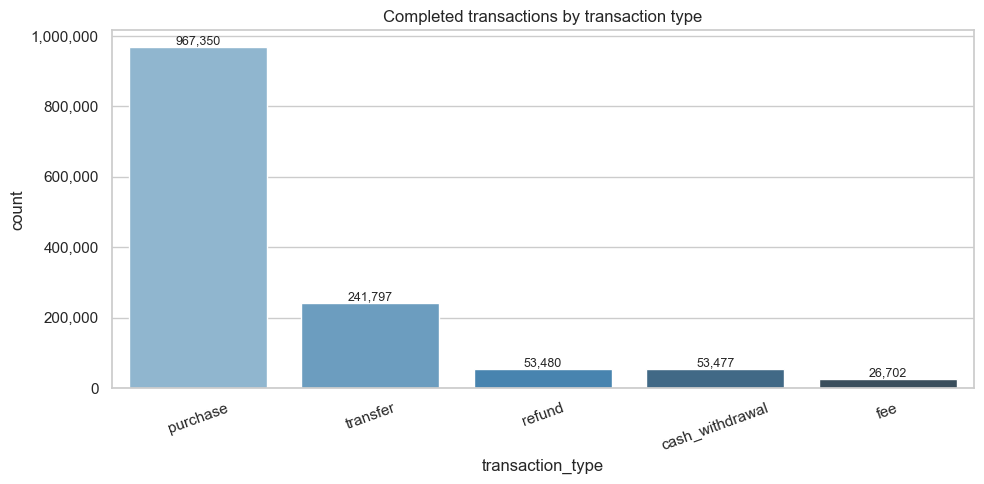

transaction_type
purchase           967350
transfer           241797
refund              53480
cash_withdrawal     53477
fee                 26702
Name: count, dtype: int64

In [140]:

# Transaction type distribution (absolute counts)
vc_tx_type = (
    df_tx["transaction_type"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=vc_tx_type.index, y=vc_tx_type.values, palette="Blues_d")
ax.set_title("Completed transactions by transaction type")
ax.set_xlabel("transaction_type")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))

for i, v in enumerate(vc_tx_type.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

vc_tx_type


This chart above shows a strongly purchase-led transaction mix: purchases account for the vast majority of completed operations, while transfer form a secondary tier. Fee, cash withdrawal and refund are comparatively small, which is expected operationally, but still useful to monitor as quality signals. Overall, user behavior looks concentrated in value-generating transactions, with limited reversal activity.

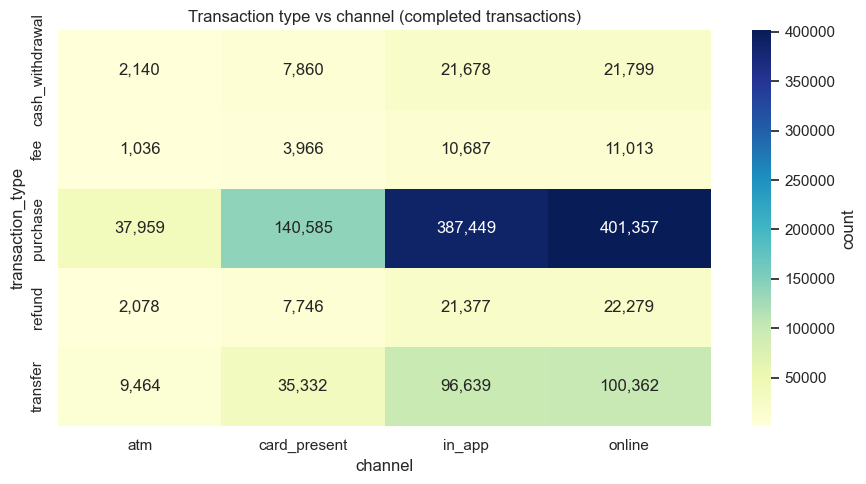

In [141]:
# Heatmap: transaction_type x channel (absolute counts)
tx_type_channel = pd.crosstab(
    df_tx["transaction_type"],
    df_tx["channel"],
).sort_index()

plt.figure(figsize=(9, 5))
ax = sns.heatmap(
    tx_type_channel,
    annot=True,
    fmt=",d",
    cmap="YlGnBu",
    cbar_kws={"label": "count"},
)
ax.set_title("Transaction type vs channel (completed transactions)")
ax.set_xlabel("channel")
ax.set_ylabel("transaction_type")

plt.tight_layout()
plt.show()


**Purchases** dominate overall volume. For purchases, **online** (401,357) slightly edges **in_app** (387,449); **card_present** (140,585) is next, and **atm** (37,959) is far smaller. **Transfers** follow the same digital skew (**online** 100,362 vs **in_app** 96,639). **ATM** is the smallest channel for every transaction type—physical rails are niche, not the default journey.

**Actionable insight:** Invest jointly in **web + app** purchase funnels (A/B by step, latency, failures) since both carry the majority of revenue-adjacent volume. Treat **card_present** as a partner/merchant lane worth its own CAC and experience KPIs. Revisit **ATM** economics—optimize for a small “cash access” segment or trim fixed cost if volume stays flat. For **transfers**, prioritize digital capabilities (limits, scheduling, instant settlement) where users already cluster.

**Segmentation note:** Channel *ranking* looks similar across transaction types (digital first, ATM last), so clusters will likely separate more on **intensity, ticket, and product mix** than on a radically different channel preference—use channel shares as supporting features alongside RFM.


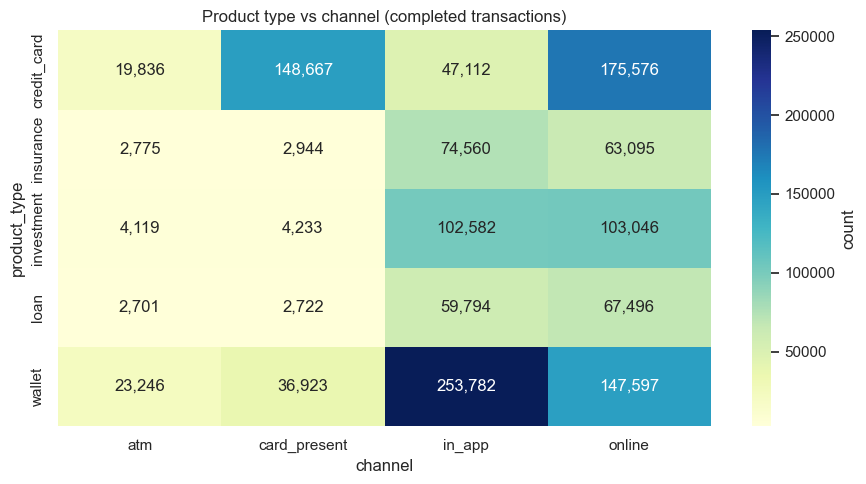

In [142]:
# Heatmap: product_type x channel (absolute counts)
tx_type_channel = pd.crosstab(
    df_tx["product_type"],
    df_tx["channel"],
).sort_index()

plt.figure(figsize=(9, 5))
ax = sns.heatmap(
    tx_type_channel,
    annot=True,
    fmt=",d",
    cmap="YlGnBu",
    cbar_kws={"label": "count"},
)
ax.set_title("Product type vs channel (completed transactions)")
ax.set_xlabel("channel")
ax.set_ylabel("product_type")

plt.tight_layout()
plt.show()


Wallet concentrates in in_app and online, which matches a mobile-first, everyday payments story—prioritize app/Web reliability, limits, and instant notifications on those rails. Credit card activity is relatively strong on card_present and online, so treat in-store and e-commerce partnerships as first-class journeys, not only app flows. Investment, insurance, and loan skew heavily digital (in_app / online) with modest ATM / card_present use—optimize for remote onboarding, education, and frictionless digital servicing; physical channels are niche for these lines.

Actionable insight: Set per-product channel KPIs (conversion, ticket, failure rate) instead of one global funnel: wallet = app/Web growth; credit card = card_present + online acceptance; long-tail products = digital origination and support. Use this matrix to decide where marketing spend and engineering capacity go per product family, and to spot misrouting (e.g., high ATM wallet volume) for fraud or UX review.



<a id="part-2"></a>

## Part 2 — RFM metrics and Feature Engineering

**Goal:** compute customer-level **RFM metrics** from retained completed transactions, engineer supporting **behavioral features** for clustering, and prepare a clean feature matrix for segmentation analysis.

[↑ Back to summary](#summary)

### Checkpoint — customer feature matrix

We build **`df_features`** with `build_customer_feature_matrix(...)`: all **numeric** inputs (behavioral RFM, tenure, refund rate, etc.). **No labels** are passed into this matrix for clustering downstream.


In [143]:
from pathlib import Path
import sys

# Make local src package importable when notebook kernel is not launched via Poetry.
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import importlib
import fintech_ai_segmentation.rfm_features as rfm

rfm = importlib.reload(rfm)
build_customer_feature_matrix = rfm.build_customer_feature_matrix
build_preprocessing_pipeline = rfm.build_preprocessing_pipeline
drop_correlated_splits = rfm.drop_correlated_splits

df_features = build_customer_feature_matrix(
    df_tx,
    df_customer_products,
    df_customers,
    as_of_date,
)
print("df_features shape:", df_features.shape)
display(df_features.head())


df_features shape: (8000, 17)


,customer_id,age,acquisition_cost,tenure_days,recency_days,frequency_total,monetary_total,monetary_purchase,monetary_transfer,monetary_cash_withdrawal,refund_rate,avg_ticket,avg_days_between_tx,products_owned,monetary_purchase_share,monetary_transfer_share,monetary_cash_withdrawal_share
0,0b8f3bda-d929-4111-abd9-992ac76066a9,39,27.79,981.0,28.0,780.0,174621.79,130432.68,31416.73,7130.89,0.042945,223.874090,0.899945,3.0,0.746944,0.179913,0.040836
1,f96dacb9-92bb-4094-977c-0de351bebff0,45,222.02,882.0,0.0,821.0,184915.37,137283.98,36888.43,6389.74,0.043124,225.231876,0.889248,3.0,0.742415,0.199488,0.034555
2,137009b3-c01b-4cb1-9b73-6096c094ea87,29,39.81,1255.0,243.0,565.0,129816.47,99274.61,19544.12,7518.31,0.042373,229.763664,0.859790,1.0,0.764730,0.150552,0.057915
3,15882a3d-ff7e-44ac-9a9c-54028f22d4e6,38,52.54,1029.0,28.0,742.0,163106.58,119394.23,29866.83,7399.50,0.041344,219.820189,0.945594,4.0,0.732001,0.183112,0.045366
4,4ad24923-433d-4cbb-a335-3603a07f764c,29,199.99,866.0,1.0,827.0,182653.19,133130.91,36654.15,8658.80,0.037253,220.862382,0.881939,2.0,0.728873,0.200676,0.047406


### Clustering sample, composition shares, and split pruning

- **Filter:** keep customers with **`frequency_total >= 1`** (at least one non-refund transaction in the analysis window).
- **Composition:** **`monetary_*_share`** columns come from **`add_monetary_type_shares`** in [`rfm_features.py`](../../src/fintech_ai_segmentation/rfm_features.py) (called by **`build_customer_feature_matrix`**) — purchase / transfer / cash withdrawal shares of total spend, capturing *how* the wallet is used, not only intensity.
- **Prune:** `drop_correlated_splits` removes raw monetary split columns that are almost perfectly aligned with **`monetary_total`**, to avoid double-weighting spend in Euclidean distance.


In [144]:
# Reload module so we always pick up the current ``drop_correlated_splits``
# (re-assigning ``drop_correlated_splits = rfm...`` in an earlier cell is easy to stale-cache).
import importlib

import fintech_ai_segmentation.rfm_features as rfm

rfm = importlib.reload(rfm)

df_clustering = df_features.loc[df_features["frequency_total"] >= 1].copy()
n_all = len(df_features)
n_clustering = len(df_clustering)

df_clustering, dropped_cols, corr_monetary_splits = rfm.drop_correlated_splits(
    df_clustering, threshold=0.9
)

if corr_monetary_splits is not None:
    display(
        corr_monetary_splits.style.format("{:.4f}").set_caption(
            "Pearson correlation: monetary_total vs raw split columns (before drop)"
        )
    )

display(
    pd.DataFrame(
        [
            {
                "customers_all": n_all,
                "clustering_n_freq_ge_1": n_clustering,
                "n_split_cols_dropped": len(dropped_cols),
            }
        ]
    )
)

if dropped_cols:
    display(pd.DataFrame({"dropped_split_column": dropped_cols}))
else:
    display(pd.DataFrame({"note": ["No raw split columns dropped at threshold 0.9."]}))


,monetary_total,monetary_purchase,monetary_transfer,monetary_cash_withdrawal
monetary_total,1.0000,0.9995,0.9939,0.9682
monetary_purchase,0.9995,1.0000,0.9905,0.9646
monetary_transfer,0.9939,0.9905,1.0000,0.9609
monetary_cash_withdrawal,0.9682,0.9646,0.9609,1.0000


,customers_all,clustering_n_freq_ge_1,n_split_cols_dropped
0,8000,4884,3


,dropped_split_column
0,monetary_purchase
1,monetary_transfer
2,monetary_cash_withdrawal


### Correlation structure (preprocessing inputs)

We inspect **linear** correlations among columns that will enter **`StandardScaler`** (after `log1p` / `sqrt` where configured). **`monetary_total`** is kept in the frame for QC but **excluded** from clustering features to avoid double-counting spend alongside frequency/ticket.


corr(frequency_total, avg_ticket): 0.7934


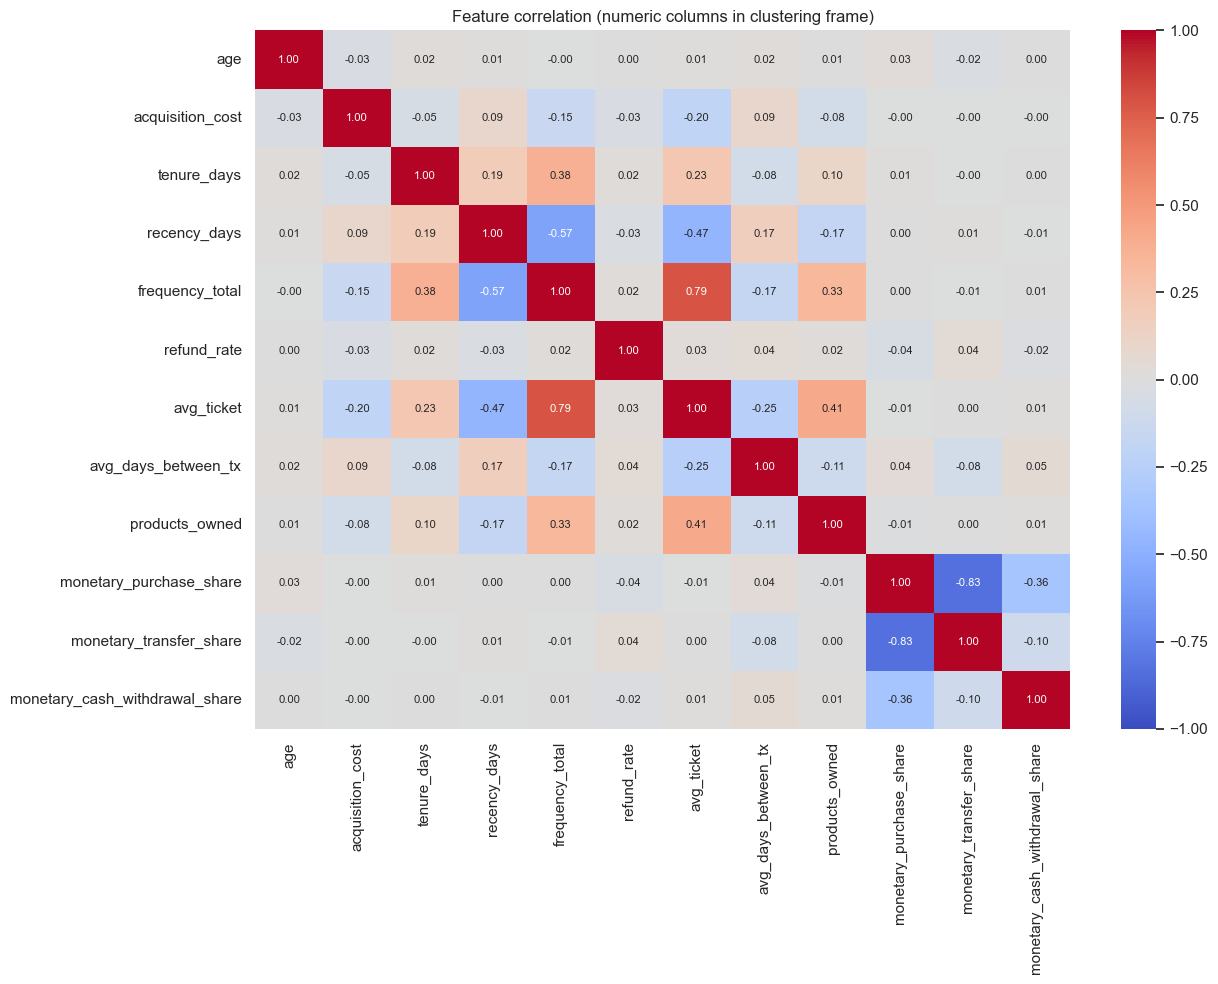

In [145]:
feature_cols = [
    c for c in df_clustering.columns if c not in {"customer_id", "monetary_total"}
]
if {"frequency_total", "avg_ticket"}.issubset(df_clustering.columns):
    corr_freq_ticket = df_clustering[["frequency_total", "avg_ticket"]].corr().iloc[0, 1]
    print(f"corr(frequency_total, avg_ticket): {corr_freq_ticket:.4f}")

_corr = df_clustering[feature_cols].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(
    _corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
)
plt.title("Feature correlation (numeric columns in clustering frame)")
plt.tight_layout()
plt.show()


### Raw distributions (before `log1p` / `sqrt`)

Skew-heavy axes (recency, frequency, ticket, …) are **not** Gaussian yet — that is expected. The preprocessing pipeline applies **`log1p`** to those columns before scaling so k-means distances are not dominated by a thin tail of extreme users.


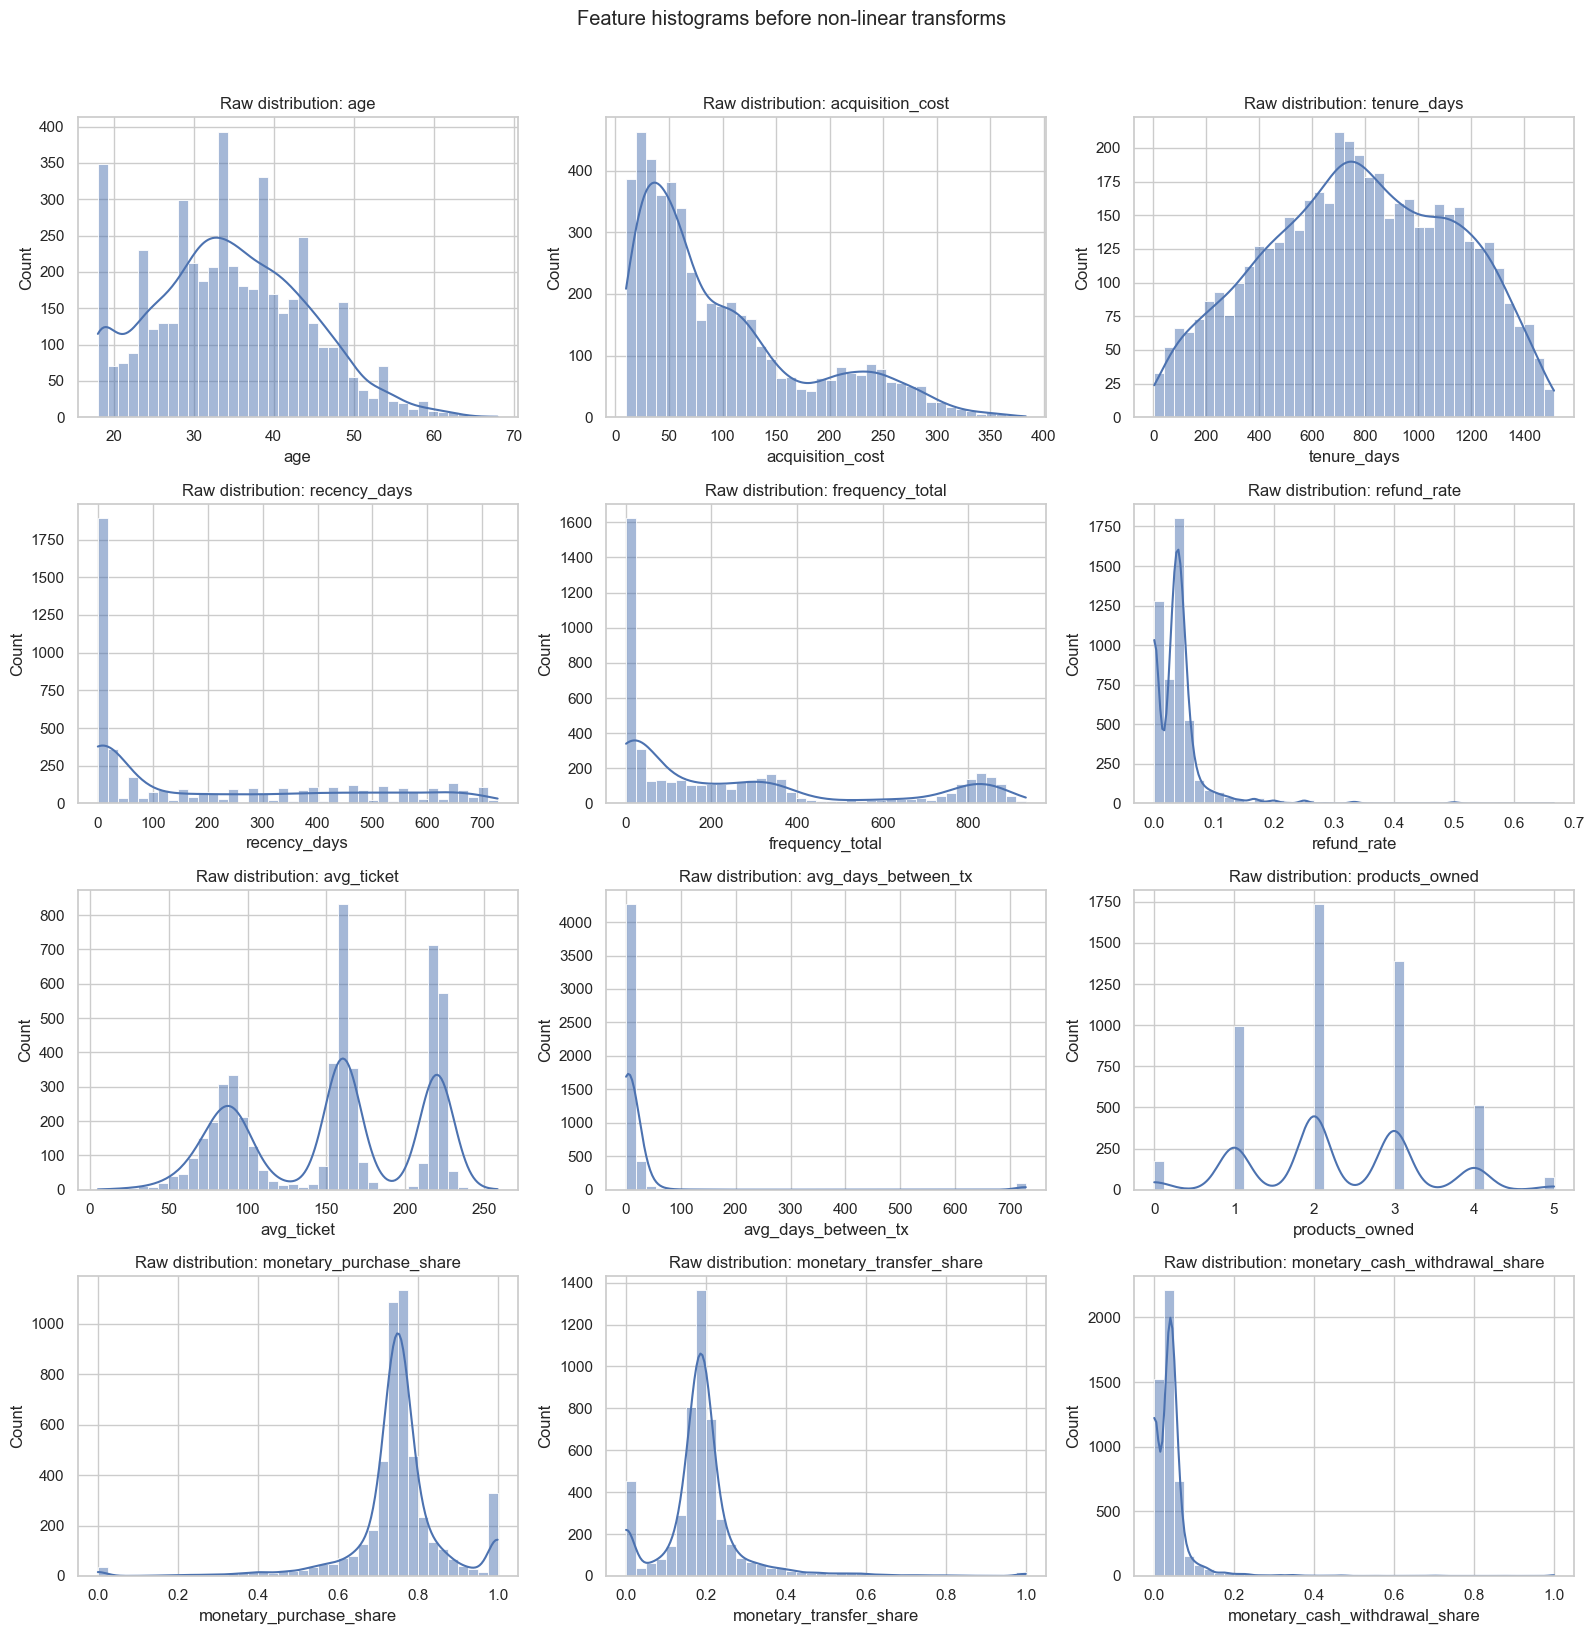

In [146]:
plot_cols = [c for c in feature_cols if c != "customer_id"]
if plot_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(plot_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        sns.histplot(df_clustering[col].dropna(), bins=40, kde=True, ax=axes[i])
        axes[i].set_title(f"Raw distribution: {col}")

    for j in range(len(plot_cols), len(axes)):
        axes[j].axis("off")

    plt.suptitle("Feature histograms before non-linear transforms", y=1.02)
    plt.tight_layout()
    plt.show()


### Preprocessing fit (`ColumnTransformer` + `StandardScaler`)

`build_preprocessing_pipeline(feature_cols)` applies **`log1p`** to right-skewed magnitudes, **`sqrt`** to **`refund_rate`**, passes through remaining numeric columns, then **`StandardScaler`** on **all** transformed features — required so k-means is not axis-dominated by BRL scale or mixed units.


In [147]:
preproc = build_preprocessing_pipeline(feature_cols)
X_scaled = preproc.fit_transform(df_clustering[feature_cols])

print("X_scaled shape:", X_scaled.shape)

log_cols = [c for c in rfm.LOG1P_COLS if c in feature_cols]
sqrt_cols = [c for c in rfm.SQRT_COLS if c in feature_cols and c not in log_cols]
pass_cols = [c for c in feature_cols if c not in log_cols and c not in sqrt_cols]
out_cols = log_cols + sqrt_cols + pass_cols

scaled_preview = pd.DataFrame(X_scaled, columns=out_cols)
display(scaled_preview.describe().T[["mean", "std", "min", "max"]].head(12))
display(df_clustering.head())

for _col in [
    "monetary_purchase",
    "monetary_transfer",
    "monetary_cash_withdrawal",
]:
    if _col not in df_clustering.columns:
        df_clustering[_col] = 0.0

X_scaled shape: (4884, 12)


,mean,std,min,max
recency_days,4.655481e-17,1.000102,-1.375276,1.186574
frequency_total,2.793288e-16,1.000102,-1.990366,1.290796
avg_ticket,-6.983221e-16,1.000102,-7.484448,1.435485
avg_days_between_tx,-1.396644e-16,1.000102,-1.230089,4.315252
acquisition_cost,0.000000e+00,1.000102,-2.183421,1.968584
refund_rate,-1.396644e-16,1.000102,-1.475565,5.933799
age,3.273385e-16,1.000102,-1.729271,3.502699
tenure_days,-1.163870e-17,1.000102,-2.178048,2.057824
products_owned,-6.983221e-17,1.000102,-2.139215,2.579812
monetary_purchase_share,-1.083854e-16,1.000102,-5.920320,1.973871


,customer_id,age,acquisition_cost,tenure_days,recency_days,frequency_total,monetary_total,refund_rate,avg_ticket,avg_days_between_tx,products_owned,monetary_purchase_share,monetary_transfer_share,monetary_cash_withdrawal_share
0,0b8f3bda-d929-4111-abd9-992ac76066a9,39,27.79,981.0,28.0,780.0,174621.79,0.042945,223.874090,0.899945,3.0,0.746944,0.179913,0.040836
1,f96dacb9-92bb-4094-977c-0de351bebff0,45,222.02,882.0,0.0,821.0,184915.37,0.043124,225.231876,0.889248,3.0,0.742415,0.199488,0.034555
2,137009b3-c01b-4cb1-9b73-6096c094ea87,29,39.81,1255.0,243.0,565.0,129816.47,0.042373,229.763664,0.859790,1.0,0.764730,0.150552,0.057915
3,15882a3d-ff7e-44ac-9a9c-54028f22d4e6,38,52.54,1029.0,28.0,742.0,163106.58,0.041344,219.820189,0.945594,4.0,0.732001,0.183112,0.045366
4,4ad24923-433d-4cbb-a335-3603a07f764c,29,199.99,866.0,1.0,827.0,182653.19,0.037253,220.862382,0.881939,2.0,0.728873,0.200676,0.047406


**Definitions (feature matrix for clustering)** — All features are numeric. Behavioral: `recency_days`, `frequency_total`, `avg_ticket`, `avg_days_between_tx`, `refund_rate`, monetary mix columns (subject to `drop_correlated_splits`), **`monetary_*_share`**, `tenure_days`, `age`, `acquisition_cost`, `products_owned`. **`monetary_total`** is retained for reconciliation only and **excluded** from `feature_cols`.

### Feature engineering decisions (Part 2 lock-in)

- **Eligibility:** `frequency_total >= 1` defines customers with observable engagement for behavioral clustering.
- **Composition shares:** purchase/transfer/cash withdrawal shares add **orthogonal** “wallet usage pattern” signal on top of intensity.
- **Collinearity:** redundant raw split columns vs `monetary_total` are dropped when |corr| > 0.9.
- **Scaling:** every column in `feature_cols` is transformed then scaled — k-means uses Euclidean distance in this space.


<a id="part-3"></a>

## Part 3 — K-means: choosing **k** and profiling clusters

**Goal:** evaluate cluster structure for **`k = 2..7`** using internal clustering diagnostics: **inertia** (elbow intuition), **mean silhouette** (separation quality), **Davies-Bouldin** (compactness/separation; lower is better), and **Calinski-Harabasz** (between-vs-within dispersion; higher is better). We also inspect **silhouette diagrams** per **`k`**, then fix an **operational `k=3`** and profile clusters.

**Production note:** we do **not** use hidden labels or external “accuracy” metrics here — only geometry in feature space and interpretability of resulting groups.


In [148]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_samples,
    silhouette_score,
)

k_values = list(range(2, 8))
rows = []
labels_by_k = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    labels_by_k[k] = labels
    rows.append(
        {
            "k": k,
            "inertia": float(km.inertia_),
            "silhouette": float(silhouette_score(X_scaled, labels)),
            "davies_bouldin": float(davies_bouldin_score(X_scaled, labels)),
            "calinski_harabasz": float(calinski_harabasz_score(X_scaled, labels)),
        }
    )

k_eval = pd.DataFrame(rows)
k_eval["inertia_prev"] = k_eval["inertia"].shift(1)
k_eval["inertia_drop_pct"] = (
    (k_eval["inertia_prev"] - k_eval["inertia"]) / k_eval["inertia_prev"]
)

k_silhouette_max = int(k_eval.loc[k_eval["silhouette"].idxmax(), "k"])
k_dbi_min = int(k_eval.loc[k_eval["davies_bouldin"].idxmin(), "k"])
k_ch_max = int(k_eval.loc[k_eval["calinski_harabasz"].idxmax(), "k"])
k_selected = 3

display(
    k_eval[
        [
            "k",
            "inertia",
            "inertia_drop_pct",
            "silhouette",
            "davies_bouldin",
            "calinski_harabasz",
        ]
    ]
    .sort_values("k")
    .reset_index(drop=True)
)
print("Silhouette-max k:", k_silhouette_max)
print("Davies-Bouldin-min k:", k_dbi_min)
print("Calinski-Harabasz-max k:", k_ch_max)
print("Operational k_selected:", k_selected)


,k,inertia,inertia_drop_pct,silhouette,davies_bouldin,calinski_harabasz
0,2,44872.174505,NaN,0.291597,1.676389,1494.429472
1,3,39802.352058,0.112984,0.294530,1.709499,1153.077178
2,4,36761.912033,0.076388,0.147976,1.943894,966.660903
3,5,34056.708759,0.073587,0.156103,1.713959,879.312146
4,6,31625.692181,0.071381,0.169174,1.716301,832.359316
5,7,29656.980694,0.062250,0.162424,1.651855,793.484467


Silhouette-max k: 3
Davies-Bouldin-min k: 7
Calinski-Harabasz-max k: 2
Operational k_selected: 3


### Elbow and mean silhouette (line charts)

Use these plots together: the **elbow** is often ambiguous on marketing/behavioral data; **mean silhouette** penalises overlap but can favour **too few** clusters. The next subsection shows **full silhouette blades** per **`k`** (per-sample coefficients).


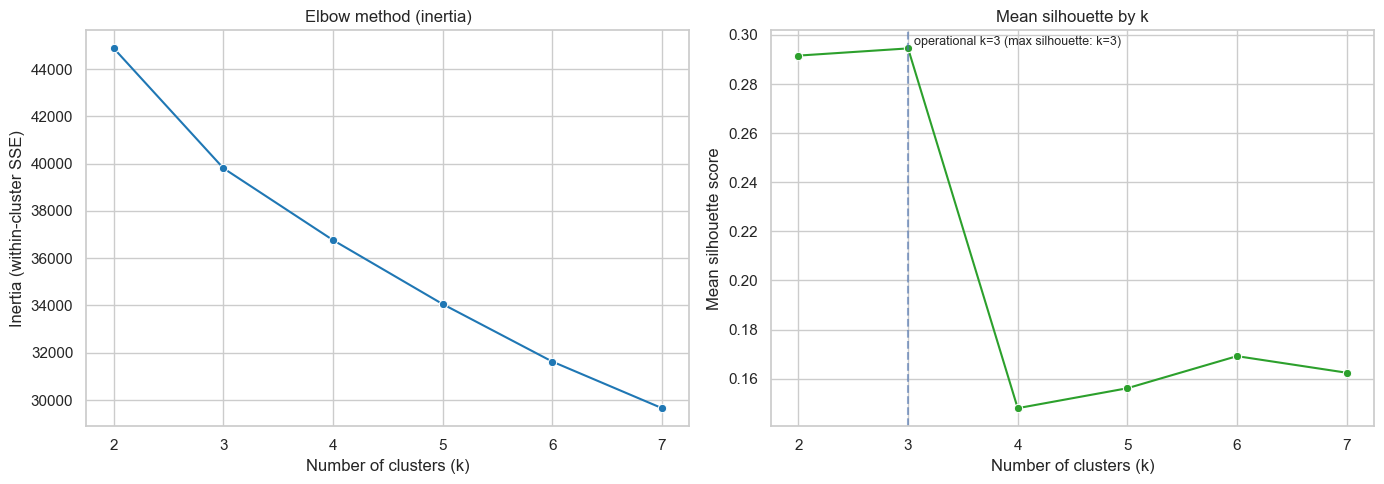

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=k_eval, x="k", y="inertia", marker="o", ax=axes[0], color="#1f77b4")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")

sns.lineplot(
    data=k_eval,
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[1],
    color="#2ca02c",
)
axes[1].set_title("Mean silhouette by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Mean silhouette score")
axes[1].axvline(k_selected, linestyle="--", alpha=0.6)
axes[1].text(
    k_selected + 0.05,
    k_eval["silhouette"].max(),
    f"operational k={k_selected} (max silhouette: k={k_silhouette_max})",
    va="bottom",
    fontsize=9,
)

plt.tight_layout()
plt.show()


### Silhouette diagrams per k (full coefficient profiles)

Each panel sorts samples by cluster blocks. The vertical dashed line is the **mean** silhouette for that **`k`**. Use this to spot **over-splitting** (many small negative slices) vs **stable** separation.


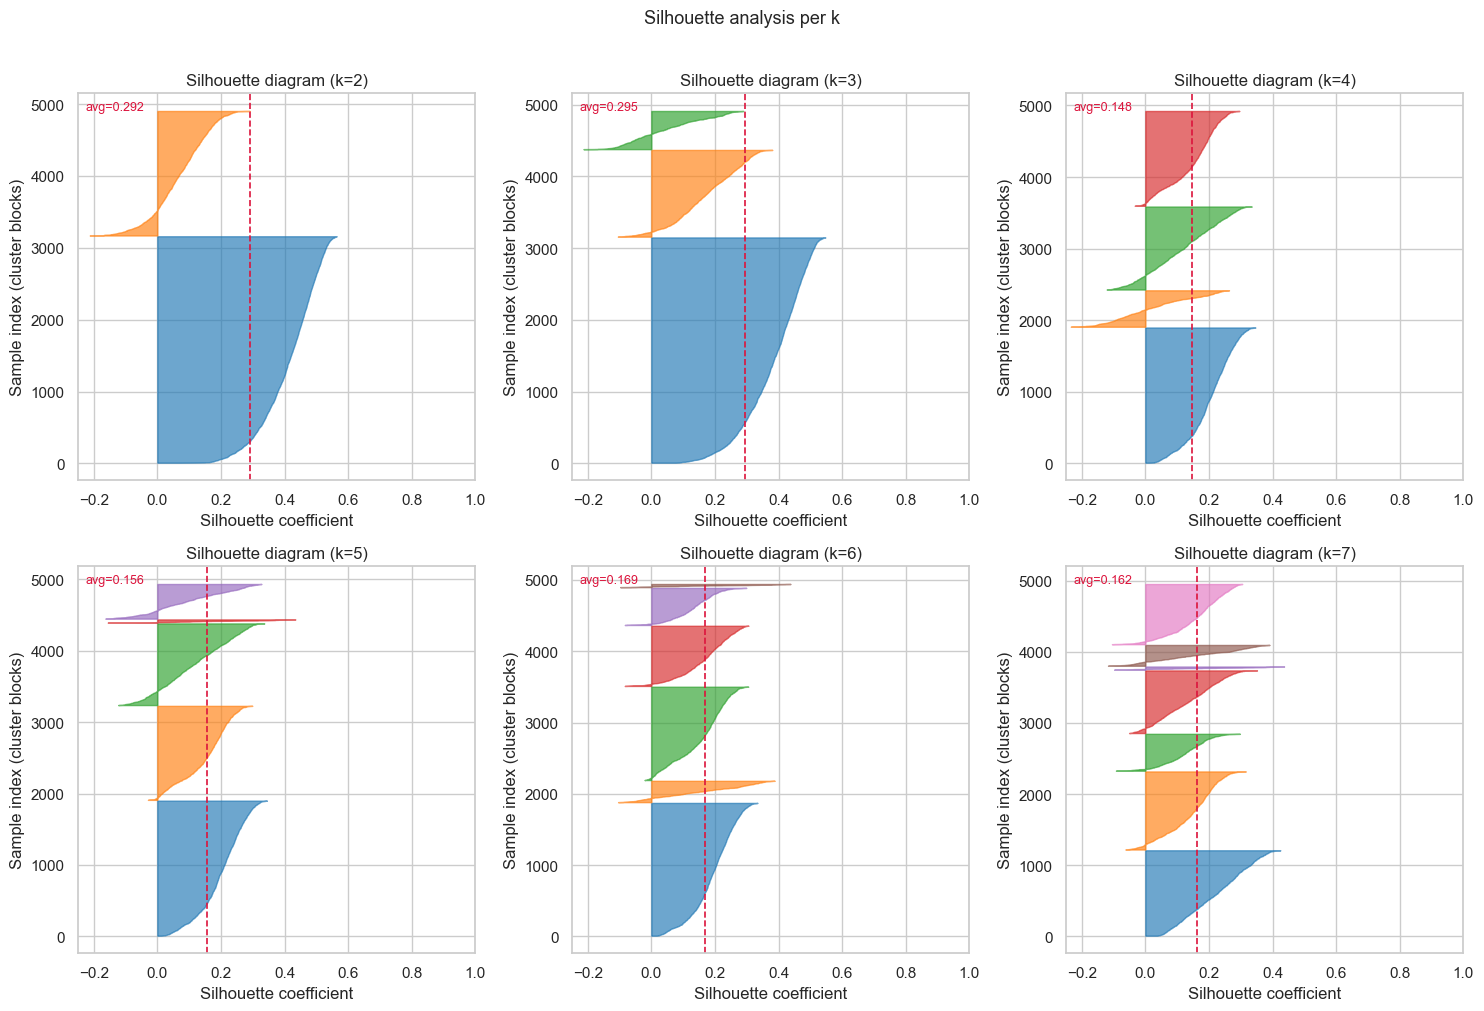

In [ ]:
fig_sil, axes_sil = plt.subplots(2, 3, figsize=(15, 10))
axes_sil = axes_sil.flatten()

for ax_idx, k in enumerate(k_values):
    ax = axes_sil[ax_idx]
    cluster_labels = labels_by_k[k]
    sil_avg = float(k_eval.loc[k_eval["k"] == k, "silhouette"].iloc[0])
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = plt.cm.tab10(i % 10)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.65,
        )
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color="crimson", linestyle="--", linewidth=1.2)
    ax.set_title(f"Silhouette diagram (k={k})")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Sample index (cluster blocks)")
    ax.set_xlim(-0.25, 1.0)
    ax.text(
        0.02,
        0.98,
        f"avg={sil_avg:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        color="crimson",
    )

plt.suptitle("Silhouette analysis per k", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


### Chart interpretation — elbow, mean silhouette, and silhouette diagrams

**Elbow (inertia)** — Inertia always decreases as **`k`** increases. Look for **diminishing returns** (successive merges of inertia drops), but behavioral datasets often yield a **soft** elbow.

**Mean silhouette** — Summarises how cleanly points match their nearest cluster vs neighbours. Higher is better, but the maximising **`k`** can be **too coarse** for CRM actions.

**Silhouette diagrams** — Reveal **per-cluster** weakness: wide negative mass in a cluster means that group is not well-separated in the current feature space.

**Decision (this notebook):** we lock **`k = 3`** Although internal indices disagree on a unique optimum, it was selected as the best trade-off between geometric quality and CRM actionability.


### Decision checkpoint — fit k-means at operational k

We fit **one** production-style model at **`k = k_selected`**, assign **`cluster_k3`**, and profile clusters below (PCA is **visualisation only** — not used to fit k-means).


In [151]:
k_fit = int(k_selected)
km3 = KMeans(n_clusters=k_fit, random_state=42, n_init=20)
labels_k3 = km3.fit_predict(X_scaled)

cluster_sizes = pd.Series(labels_k3).value_counts().sort_index()
print("Cluster sizes (k=%d):" % k_fit)
print(cluster_sizes.to_string())


Cluster sizes (k=3):
0    3141
1    1210
2     533


### Visualising clusters (PCA for 2D projection + feature profiles)

Two complementary views:

- **2D PCA scatter** of **`X_scaled`** — helpful to eyeball overlap; variance explained is usually modest because behavior is high-dimensional.
- **Boxplots + mean/median table** on interpretable raw features (including **`monetary_*_share`**) — primary business readout.


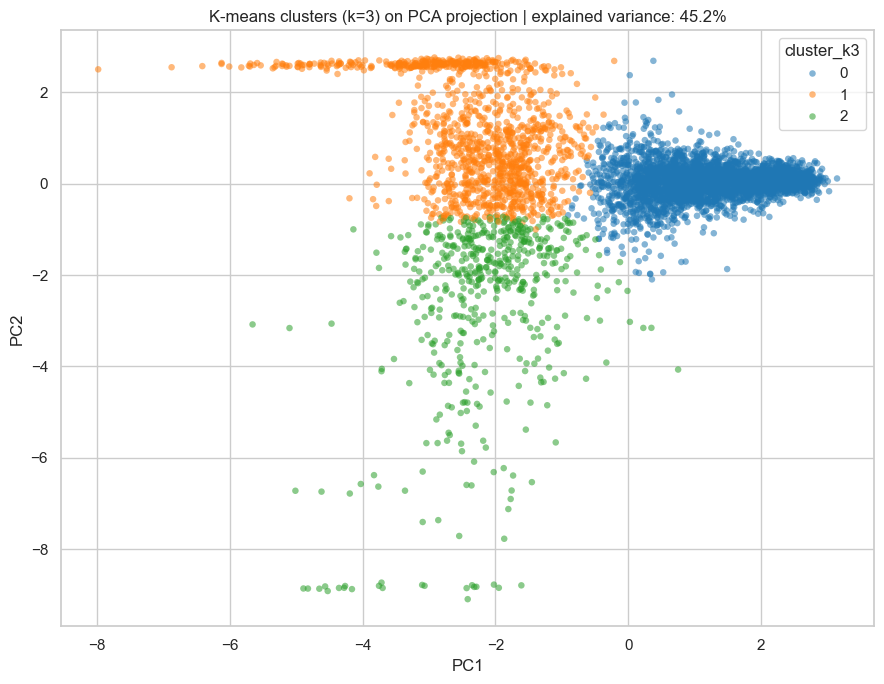

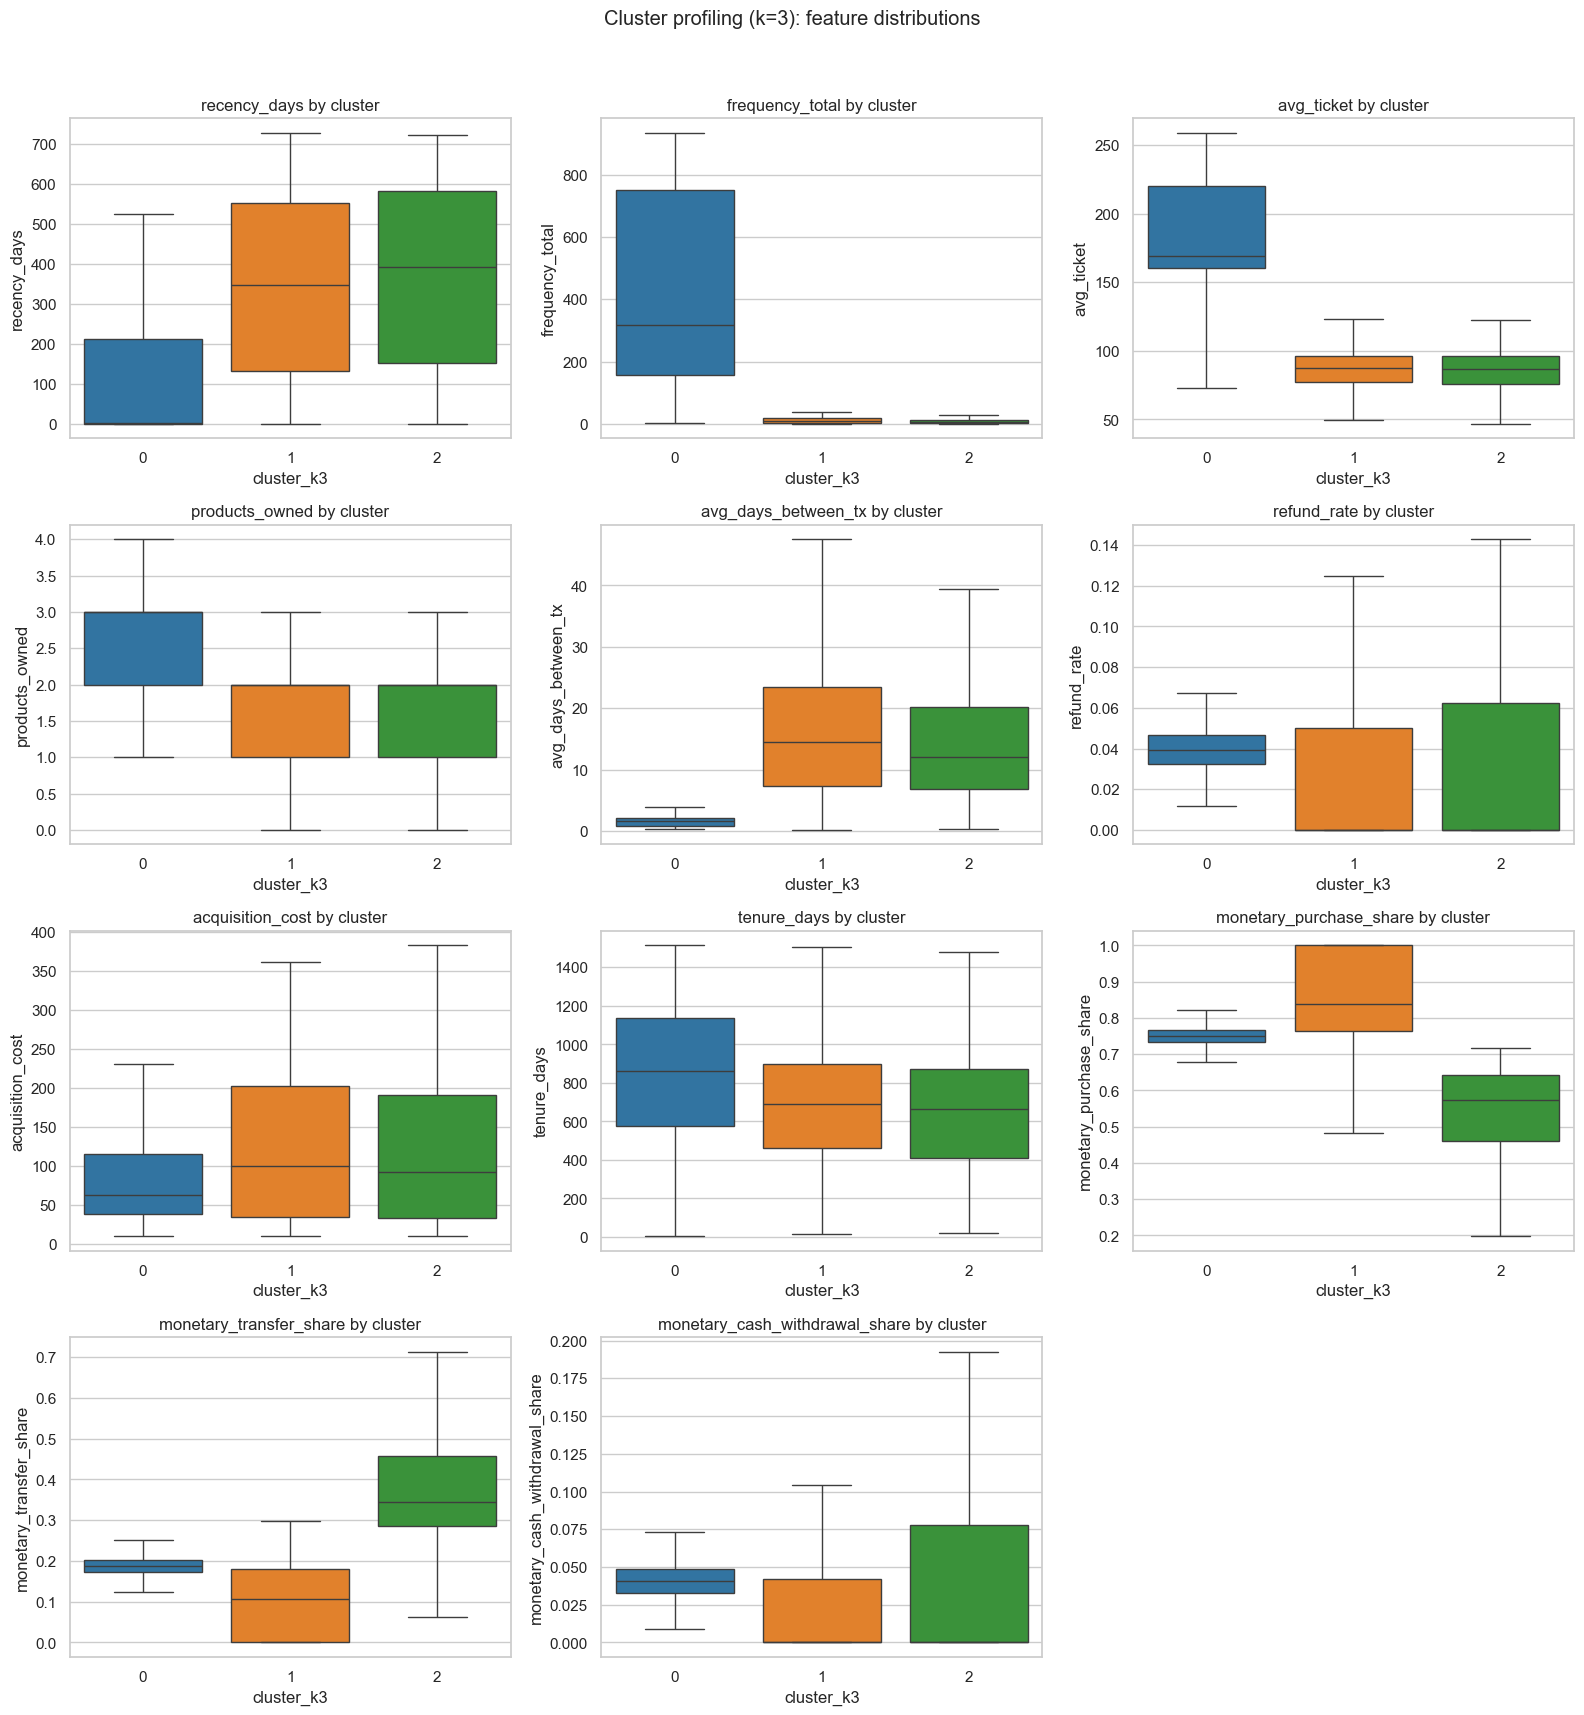

recency_days        frequency_total        avg_ticket          \
                   mean median            mean median       mean  median   
cluster_k3                                                                 
0                127.89    2.0          404.08  318.0     188.09  169.18   
1                349.17  347.0           12.27   10.0      87.65   87.58   
2                366.68  393.0            9.86    7.0      88.49   86.69   

           products_owned        avg_days_between_tx         ... tenure_days  \
                     mean median                mean median  ...        mean   
cluster_k3                                                   ...               
0                    2.57    3.0                1.55   1.69  ...      836.62   
1                    1.70    2.0               60.67  14.46  ...      689.90   
2                    1.75    2.0               43.24  12.05  ...      654.80   

                  monetary_purchase_share        monetary_transfer_share  \
           median                    mean median                    mean   
cluster_k3                                                                 
0           861.0                    0.75   0.75                    0.19   
1           691.0                    0.85   0.84                    0.10   
2           665.0                    0.52   0.57                    0.39   

                  monetary_cash_withdrawal_share        refund_rate         
           median                           mean median        mean median  
cluster_k3                                                                  
0            0.19                           0.04   0.04        0.04   0.04  
1            0.11                           0.03   0.00        0.03   0.00  
2            0.35                           0.07   0.00        0.04   0.00  

[3 rows x 22 columns]

In [152]:
from sklearn.decomposition import PCA

plot_df = df_clustering.copy()
plot_df["cluster_k3"] = labels_k3

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plot_df["pc1"] = X_pca[:, 0]
plot_df["pc2"] = X_pca[:, 1]

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="cluster_k3",
    palette="tab10",
    alpha=0.55,
    s=22,
    linewidth=0,
)
plt.title(
    f"K-means clusters (k={k_fit}) on PCA projection | "
    f"explained variance: {(pca.explained_variance_ratio_.sum() * 100):.1f}%"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="cluster_k3")
plt.tight_layout()
plt.show()

feature_view = [
    c
    for c in [
        "recency_days",
        "frequency_total",
        "avg_ticket",
        "products_owned",
        "avg_days_between_tx",
        "refund_rate",
        "acquisition_cost",
        "tenure_days",
        "monetary_purchase_share",
        "monetary_transfer_share",
        "monetary_cash_withdrawal_share",
    ]
    if c in plot_df.columns
]

n_cols = 3
n_rows = int(np.ceil(len(feature_view) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(feature_view):
    sns.boxplot(
        data=plot_df,
        x="cluster_k3",
        y=col,
        hue="cluster_k3",
        ax=axes[i],
        palette="tab10",
        showfliers=False,
    )
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()
    axes[i].set_title(f"{col} by cluster")
    axes[i].set_xlabel("cluster_k3")

for j in range(len(feature_view), len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Cluster profiling (k={k_fit}): feature distributions", y=1.02)
plt.tight_layout()
plt.show()

profile_cols = [c for c in feature_view if c != "refund_rate"] + (
    ["refund_rate"] if "refund_rate" in feature_view else []
)
cluster_profile = (
    plot_df.groupby("cluster_k3", as_index=True)[profile_cols]
    .agg(["mean", "median"])
    .round(2)
)
display(cluster_profile)


### Brief read of k-means results (k = 3)

The `k=3` solution gives a practical behavioural split: one **engaged/intense** cluster (low recency, high frequency), plus two **lower-engagement** groups with different spend rhythm and mix. In this notebook, cluster IDs are only labels (`0/1/2`), so we interpret clusters by medians/spread in the boxplots, not by the numeric ID itself.

This is a useful operational baseline, but behaviour-only clustering can still hide product-level differences. Next, we profile these same three clusters with **product penetration** and **activity gap** to surface activation opportunities.

### Deep-dive plan: product penetration and activity gap by cluster

To better understand business potential inside each behavioural cluster, we now compare:

- **Product penetration**: share of customers in each cluster that currently own each product type.
- **Product activity**: share of customers in each cluster with at least one completed transaction in that product type over the last 6 months.
- **Gap (`penetration - activity`)**: where ownership exists but usage lags, indicating activation opportunity.

This keeps the same `k=3` clusters and adds a product lens before final recommendations.

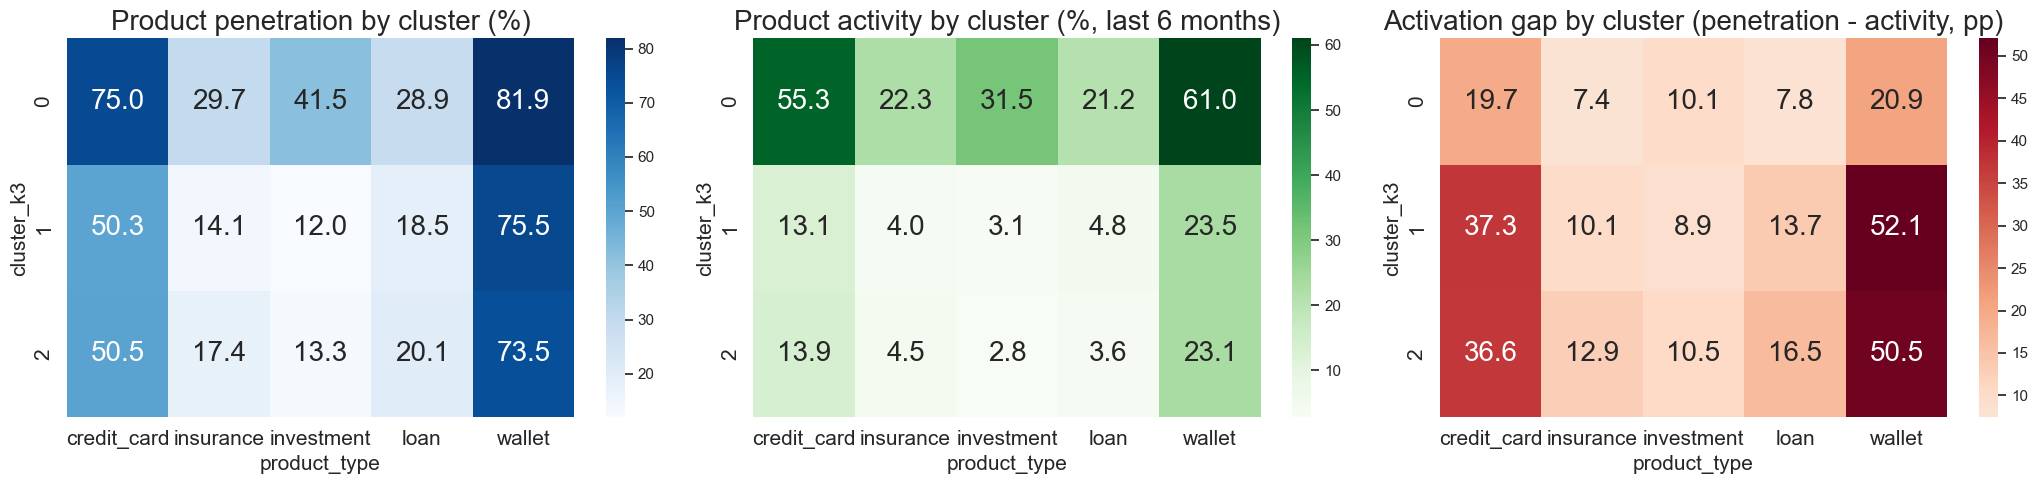

In [153]:
# Standard clusters (k=3) business read: product penetration + product activity gap

# 0) Resolve standard cluster assignment (pre one-hot/product-share experiments)
if "df_clustering" not in globals():
    raise ValueError("df_clustering not found. Run Part 3 (standard k=3 clustering) first.")

if "cluster_k3" not in df_clustering.columns:
    if "labels_k3" in globals() and len(labels_k3) == len(df_clustering):
        df_clustering = df_clustering.copy()
        df_clustering["cluster_k3"] = labels_k3
    else:
        raise ValueError("cluster_k3 not found in df_clustering and labels_k3 is unavailable.")

cluster_map = df_clustering[["customer_id", "cluster_k3"]].copy()

# 1) Product penetration (ownership) by cluster
cp_active = df_customer_products.copy()
if "is_active" in cp_active.columns:
    cp_active = cp_active[cp_active["is_active"] == True].copy()

cp_prod = cp_active.merge(df_products[["product_id", "product_type"]], on="product_id", how="left")
own_pairs = cp_prod[["customer_id", "product_type"]].dropna().drop_duplicates()

# Build full customer x product grid to keep the denominator correct.
# Without this grid, rates are inflated because only observed pairs are averaged.
all_product_types = sorted(df_products["product_type"].dropna().unique().tolist())
customer_product_base = (
    cluster_map.assign(_k=1)
    .merge(pd.DataFrame({"product_type": all_product_types, "_k": 1}), on="_k", how="left")
    .drop(columns="_k")
)

owner_flags = customer_product_base.merge(
    own_pairs.assign(owner_flag=1),
    on=["customer_id", "product_type"],
    how="left",
)
owner_flags["owner_flag"] = owner_flags["owner_flag"].fillna(0)

penetration = (
    owner_flags.groupby(["cluster_k3", "product_type"], as_index=False)["owner_flag"]
    .mean()
    .rename(columns={"owner_flag": "penetration_rate"})
)
penetration["penetration_rate"] *= 100

# 2) Product activity by cluster (has >=1 tx in product_type over last 6 months)
# Anchor on as_of_date; fallback to max df_tx timestamp if as_of_date is unavailable.
_as_of = pd.Timestamp(as_of_date) if "as_of_date" in globals() else pd.Timestamp(df_tx["transaction_datetime"].max())
if _as_of.tzinfo is not None:
    _as_of = _as_of.tz_localize(None)

window_start_6m = _as_of - pd.DateOffset(months=6)

tx_recent_6m = df_tx.copy()
tx_recent_6m["transaction_datetime"] = pd.to_datetime(tx_recent_6m["transaction_datetime"], errors="coerce")
if isinstance(tx_recent_6m["transaction_datetime"].dtype, pd.DatetimeTZDtype):
    tx_recent_6m["transaction_datetime"] = tx_recent_6m["transaction_datetime"].dt.tz_localize(None)

tx_recent_6m = tx_recent_6m[
    tx_recent_6m["transaction_datetime"].between(window_start_6m, _as_of, inclusive="both")
].copy()

activity_pairs = tx_recent_6m[["customer_id", "product_type"]].dropna().drop_duplicates()
activity_flags = customer_product_base.merge(
    activity_pairs.assign(active_flag=1),
    on=["customer_id", "product_type"],
    how="left",
)
activity_flags["active_flag"] = activity_flags["active_flag"].fillna(0)

activity = (
    activity_flags.groupby(["cluster_k3", "product_type"], as_index=False)["active_flag"]
    .mean()
    .rename(columns={"active_flag": "activity_rate"})
)
activity["activity_rate"] *= 100

# 3) Gap table (penetration - activity)
prod_gap = penetration.merge(activity, on=["cluster_k3", "product_type"], how="outer").fillna(0.0)
prod_gap["gap_pen_minus_act"] = prod_gap["penetration_rate"] - prod_gap["activity_rate"]

gap_pivot = prod_gap.pivot(index="cluster_k3", columns="product_type", values="gap_pen_minus_act")
pen_pivot = prod_gap.pivot(index="cluster_k3", columns="product_type", values="penetration_rate")
act_pivot = prod_gap.pivot(index="cluster_k3", columns="product_type", values="activity_rate")

#print("Product penetration by cluster (% customers owning active product):")
#display(pen_pivot.round(2))
#print("Product activity by cluster (% customers with >=1 tx in product, last 6 months):")
#display(act_pivot.round(2))
#print("Gap = penetration - activity (pp): positive means under-activation among owners")
#display(gap_pivot.round(2))

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

sns.heatmap(
    pen_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    ax=axes[0],
    annot_kws={"size": 20},
)
axes[0].set_title("Product penetration by cluster (%)", fontsize=20)
axes[0].set_xlabel("product_type", fontsize=15)
axes[0].set_ylabel("cluster_k3", fontsize=15)
axes[0].tick_params(axis="both", labelsize=15)

sns.heatmap(
    act_pivot,
    annot=True,
    fmt=".1f",
    cmap="Greens",
    ax=axes[1],
    annot_kws={"size": 20},
)
axes[1].set_title("Product activity by cluster (%, last 6 months)", fontsize=20)
axes[1].set_xlabel("product_type", fontsize=15)
axes[1].set_ylabel("cluster_k3", fontsize=15)
axes[1].tick_params(axis="both", labelsize=15)

sns.heatmap(
    gap_pivot,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r",
    center=0.0,
    ax=axes[2],
    annot_kws={"size": 20},
)
axes[2].set_title("Activation gap by cluster (penetration - activity, pp)", fontsize=20)
axes[2].set_xlabel("product_type", fontsize=15)
axes[2].set_ylabel("cluster_k3", fontsize=15)
axes[2].tick_params(axis="both", labelsize=15)

plt.tight_layout()
plt.show()


### Product analysis read — penetration and activation gaps

Using the same `k=3` behavioural clusters, the product lens now uses **activity in the last 6 months**. This makes the gap view a direct read of current activation headroom.

- **Cluster 0 (engaged core):** highest penetration across products, but still meaningful activation gaps (roughly ~7–21 pp). Even the strongest cluster has room to increase recent product usage.
- **Clusters 1 and 2 (lower engagement):** lower penetration in non-wallet products and **very large gaps**, especially in `wallet` and `credit_card` (roughly ~23–52 pp depending on cluster/product). This is the clearest activation opportunity.
- **Gap interpretation:** with `gap = penetration - activity_6m`, positive values mean customers own the product but did not transact recently, indicating reactivation or use-case adoption potential.

**Action implication:**
- **Cluster 0:** retain and reactivate light users with usage nudges and cross-product orchestration.
- **Clusters 1/2:** prioritize high-gap activation plays by product family (`wallet`, `credit_card`, then `loan`/`investment`), with journey-specific win-back campaigns.

### Part 3 wrap-up

**Final reading of this notebook pass**

- We keep a **k-means baseline with `k=3`** on behavioural features as the operational segmentation for this phase.
- Product diagnostics use activity defined as **>=1 transaction in the last 6 months** and a corrected denominator (full customer × product grid per cluster).
- Beyond engagement level, the clusters also differ by **usage mix** (`monetary_purchase_share` vs `monetary_transfer_share`).

### Final cluster names

- **Cluster 0 — Core Omnichannel Engaged**
  - Lowest recency, highest frequency/ticket, broader product ownership.
  - Balanced but purchase-led mix with meaningful transfer usage.

- **Cluster 1 — Dormant Purchase-First**
  - Low cadence / high recency, but when active the wallet is mostly **purchase-oriented**.
  - Higher `monetary_purchase_share`, lower `monetary_transfer_share` vs Cluster 2.

- **Cluster 2 — Dormant Transfer-Led**
  - Low cadence / high recency, with behavior tilted to **transfers/cash access**.
  - Lower `monetary_purchase_share` and clearly higher `monetary_transfer_share` vs Cluster 1.

**How product analysis refines the profiles**

- **Cluster 0:** highest penetration, yet still meaningful 6-month activation gaps (roughly ~7–21 pp).
- **Clusters 1 and 2:** lower penetration outside wallet and very large 6-month activation gaps, especially in `wallet` and `credit_card`.
- The mix split between clusters 1 and 2 matters for action design:
  - **Cluster 1 (Purchase-First):** reactivate with merchant offers, card/wallet checkout journeys, and purchase-frequency nudges.
  - **Cluster 2 (Transfer-Led):** reactivate with transfer-to-payment bridges, bill-pay/auto-pay adoption, and wallet usage expansion from transfer rails.

### Answers to business questions (Q6–Q10)

1. **Q6 — Who are the most valuable customers right now?**
   - **Core Omnichannel Engaged (Cluster 0)** is the highest immediate-value pool.

2. **Q7 — What behavioral patterns define each segment?**
   - One engaged omni-usage segment, one dormant purchase-first segment, and one dormant transfer-led segment.

3. **Q8 — What is the RFM profile of each segment?**
   - Cluster 0 concentrates favorable RFM (more recent, more frequent, stronger monetary).
   - Clusters 1/2 are less recent and less frequent, with the key difference being purchase-vs-transfer mix.

4. **Q9 — Do high-engagement customers own more products?**
   - Yes. Cluster 0 has broader product penetration, though activation gaps show further usage upside.

5. **Q10 — How does credit utilization vary across segments?**

   - Proxy read from now: `credit_card` penetration/activity is stronger in Cluster 0; clusters 1/2 show larger activation headroom.

**Operational implication**

- **Cluster 0 (Core Omnichannel Engaged):** retain and deepen value.
- **Cluster 1 (Dormant Purchase-First):** purchase-flow reactivation and merchant-led engagement.
- **Cluster 2 (Dormant Transfer-Led):** transfer-led journeys that migrate users into broader wallet/card usage.


### Part 4 — Customer analysis mart (`customer_analysis`)

This section materialises a **single customer-level table** for CRM, dashboards, and downstream models.

**Why two layers?**

- **`lifecycle_stage` (rules, everyone):** Uses the **full** completed transaction history plus the RFM window to label customers who **never qualified for k-means** (no non-refund activity in the analysis window): e.g. *new / inactive with no transactions*, *churned before the window*, or *only refunds inside the window*. These rows keep **`cluster_k3` / `cluster_name` empty** — clustering is undefined without behavioural features.
- **`cluster_k3` + `cluster_name` (k-means, eligible subset only):** Matches this notebook’s **`k=3`** fit on customers with **`frequency_total >= 1`** (non-refund txs in **Mar 2024 – Feb 2026**). Names follow the Part 3 wrap-up:
  - **0 — Core Omnichannel Engaged**
  - **1 — Dormant Purchase-First**
  - **2 — Dormant Transfer-Led**

**Columns (conceptual groups)**

| Group | Content |
| --- | --- |
| **Identity & raw `customers_raw`** | `customer_id`, demographics, `state`, `acquisition_channel`, `acquisition_cost`, `registration_date`, `true_segment` (evaluation label only). |
| **RFM window & features** | Same engineered metrics as `build_customer_feature_matrix` (`recency_days`, `frequency_total`, monetary splits, shares, `tenure_days`, …) — all anchored on **`as_of_date`** and the retained **`df_tx`** window. |
| **Global tx facts** | `first_tx_global`, `last_tx_global`, `n_tx_completed_global` from **all** completed rows in `transactions_raw` (for lifecycle rules). |
| **Segmentation outputs** | `lifecycle_stage`, optional `cluster_k3`, `cluster_name`, plus **`mart_built_at`** for lineage. |

The next cell builds **`df_customer_analysis`** in memory; the following cell **writes** it to Supabase as **`public.customer_analysis`** (`if_exists='replace'`).


### Column map — what was added to `df_customers`

`df_customer_analysis` starts from **`df_customers`** (one row per `customer_id` from `customers_raw`). Everything below is **joined or computed on top of that spine**; we did **not** re-query demographics or channel fields from new tables—they stay exactly as loaded, except where noted.

| Source | Columns | Role |
| --- | --- | --- |
| **`df_customers` (unchanged)** | `customer_id`, `age`, `state`, `acquisition_channel`, `acquisition_cost`, `registration_date`, `true_segment` | Static / acquisition attributes from the warehouse. **`age`** and **`acquisition_cost`** are taken only from here; `df_features` repeats them internally for modeling but those duplicates are dropped before the merge. |
| **`df_features`** (windowed aggregates on `df_tx` + `customer_products`) | `tenure_days`; `recency_days`; `frequency_total`; `monetary_total`; `avg_ticket`; `monetary_purchase`, `monetary_transfer`, `monetary_cash_withdrawal`; `monetary_*_share`; `refund_rate`; `avg_days_between_tx`; `products_owned` | Behavioural RFM and mix features from **`build_customer_feature_matrix`**: rolls up **non-refund** completed transactions through **`as_of_date`** inside the analysis window, plus active-product counts. |
| **Global tx rollups** (`df_transactions`, all completed history) | `first_tx_global`, `last_tx_global`, `n_tx_completed_global` | Used for **lifecycle rules** (e.g. churned before the window vs never transacted); not limited to the RFM window. |
| **K-means output** | `cluster_k3`, `cluster_name` | Assigned only for **`lifecycle_stage = active_clustered`**; cleared otherwise. |
| **Derived labels & lineage** | `lifecycle_stage`; `rfm_window_start`; `rfm_window_end_excl`; `analysis_as_of_date`; `mart_built_at` | Rules + metadata so exports are reproducible. |

If a column name appears in both a raw pull and the feature matrix, the table keeps the **customer-table** version for identity fields and attaches the **engineered** metrics as separate columns from `df_features` (see merge in the next cell).


In [155]:
# Build df_customer_analysis: customers_raw + RFM features + lifecycle_stage + k-means labels

CLUSTER_K3_NAMES = {
    0: "Core Omnichannel Engaged",
    1: "Dormant Purchase-First",
    2: "Dormant Transfer-Led",
}

NEW_NO_TX_TENURE_DAYS_MAX = 60.0

if "df_customers" not in globals() or "df_features" not in globals():
    raise RuntimeError("Run data load and df_features (build_customer_feature_matrix) first.")

if "WINDOW_START" not in globals() or "as_of_date" not in globals():
    raise RuntimeError("WINDOW_START / as_of_date not set — run the analysis-window cell first.")

if "df_clustering" not in globals() or "labels_k3" not in globals():
    raise RuntimeError("Run Part 3 k-means (df_clustering, labels_k3) first.")

# --- Ensure cluster_k3 is attached to df_clustering (same guard as product deep-dive) ---
_cl = df_clustering.copy()
if "cluster_k3" not in _cl.columns:
    if len(labels_k3) == len(_cl):
        _cl["cluster_k3"] = labels_k3
    else:
        raise ValueError("labels_k3 length does not match df_clustering.")

_cluster_map = _cl[["customer_id", "cluster_k3"]].drop_duplicates(subset=["customer_id"]).copy()
_cluster_map["cluster_name"] = _cluster_map["cluster_k3"].map(CLUSTER_K3_NAMES)

# --- Raw customers + engineered features (avoid duplicate age / acquisition_cost columns) ---
_feat_cols = [c for c in df_features.columns if c != "customer_id" and c not in {"age", "acquisition_cost"}]
df_customer_analysis = df_customers.merge(
    df_features[_feat_cols + ["customer_id"]],
    on="customer_id",
    how="left",
)

# --- Global completed-transaction timestamps (full history, not just RFM window) ---
if "df_transactions" not in globals():
    raise RuntimeError("df_transactions not loaded — run the SQL load cell first.")

_tx_times = pd.to_datetime(df_transactions["transaction_datetime"], errors="coerce")
_glob = (
    df_transactions.assign(transaction_datetime=_tx_times)
    .dropna(subset=["transaction_datetime"])
    .groupby("customer_id")["transaction_datetime"]
    .agg(first_tx_global="min", last_tx_global="max", n_tx_completed_global="count")
    .reset_index()
)

df_customer_analysis = df_customer_analysis.merge(_glob, on="customer_id", how="left")

# --- Merge cluster labels only for customers present in the clustering frame ---
df_customer_analysis = df_customer_analysis.merge(_cluster_map, on="customer_id", how="left")

# --- Lifecycle rules (everyone gets a stage; clusters only where k-means applied) ---


def _ts_naive(x):
    if pd.isna(x):
        return pd.NaT
    t = pd.to_datetime(x)
    if getattr(t, "tzinfo", None) is not None:
        return t.tz_convert(None)
    return t


_ws = _ts_naive(WINDOW_START)


def assign_lifecycle(row: pd.Series) -> str:
    freq = row.get("frequency_total")
    if pd.notna(freq) and float(freq) >= 1.0:
        return "active_clustered"

    last_g = row.get("last_tx_global")
    ten = row.get("tenure_days")

    if pd.isna(last_g):
        ten_v = float(ten) if pd.notna(ten) else 0.0
        return "new_no_tx" if ten_v <= NEW_NO_TX_TENURE_DAYS_MAX else "inactive_no_tx"

    last_g = _ts_naive(last_g)
    if pd.isna(last_g):
        ten_v = float(ten) if pd.notna(ten) else 0.0
        return "new_no_tx" if ten_v <= NEW_NO_TX_TENURE_DAYS_MAX else "inactive_no_tx"

    if last_g < _ws:
        return "churned_pre_window"

    return "refunds_only_in_window"


df_customer_analysis["lifecycle_stage"] = df_customer_analysis.apply(assign_lifecycle, axis=1)

# Clear cluster labels unless the customer was in the k-means eligible set
_not_clustered = df_customer_analysis["lifecycle_stage"] != "active_clustered"
df_customer_analysis.loc[_not_clustered, "cluster_k3"] = pd.NA
df_customer_analysis.loc[_not_clustered, "cluster_name"] = pd.NA

# --- Lineage / window metadata ---
df_customer_analysis["rfm_window_start"] = pd.Timestamp(WINDOW_START)
if "WINDOW_END_EXCL" in globals():
    df_customer_analysis["rfm_window_end_excl"] = pd.Timestamp(WINDOW_END_EXCL)
else:
    df_customer_analysis["rfm_window_end_excl"] = pd.NaT
df_customer_analysis["analysis_as_of_date"] = pd.Timestamp(as_of_date)
df_customer_analysis["mart_built_at"] = pd.Timestamp.utcnow()

# --- Tidy dtypes for SQL: naive datetimes ---
for _c in ("registration_date", "first_tx_global", "last_tx_global", "analysis_as_of_date", "mart_built_at"):
    if _c not in df_customer_analysis.columns:
        continue
    _s = pd.to_datetime(df_customer_analysis[_c], errors="coerce")
    if isinstance(_s.dtype, pd.DatetimeTZDtype):
        _s = _s.dt.tz_convert(None)
    df_customer_analysis[_c] = _s

print("df_customer_analysis:", df_customer_analysis.shape)
display(df_customer_analysis["lifecycle_stage"].value_counts())
display(df_customer_analysis.head(3))


df_customer_analysis: (8000, 31)


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_9332/2528388832.py:109: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  df_customer_analysis["mart_built_at"] = pd.Timestamp.utcnow()


lifecycle_stage
active_clustered      4884
churned_pre_window    2240
inactive_no_tx         821
new_no_tx               55
Name: count, dtype: int64

,customer_id,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment,tenure_days,recency_days,frequency_total,...,first_tx_global,last_tx_global,n_tx_completed_global,cluster_k3,cluster_name,lifecycle_stage,rfm_window_start,rfm_window_end_excl,analysis_as_of_date,mart_built_at
0,0b8f3bda-d929-4111-abd9-992ac76066a9,39,RS,organic,27.79,2023-06-23,high_value_active,981.0,28.0,780.0,...,2023-06-23 03:24:00,2026-01-31 08:50:00,1128.0,0.0,Core Omnichannel Engaged,active_clustered,2024-03-01,2026-03-01,2026-02-28 23:58:00,2026-04-09 19:27:40.694200
1,f96dacb9-92bb-4094-977c-0de351bebff0,45,CE,paid_ads,222.02,2023-09-30,high_value_active,882.0,0.0,821.0,...,2023-10-02 11:28:00,2026-02-28 06:36:00,1051.0,0.0,Core Omnichannel Engaged,active_clustered,2024-03-01,2026-03-01,2026-02-28 23:58:00,2026-04-09 19:27:40.694200
2,137009b3-c01b-4cb1-9b73-6096c094ea87,29,BA,referral,39.81,2022-09-22,high_value_active,1255.0,243.0,565.0,...,2022-09-22 13:40:00,2025-06-30 22:44:00,1149.0,0.0,Core Omnichannel Engaged,active_clustered,2024-03-01,2026-03-01,2026-02-28 23:58:00,2026-04-09 19:27:40.694200


### Upload `df_customer_analysis` to Supabase

The cell below uses **`SUPABASE_DATABASE_URL`** (same as the read path) and **`DataFrame.to_sql(..., if_exists="replace")`** to refresh **`public.customer_analysis`**. Re-running the notebook overwrites the table; adjust to `append` or a staging table if you need history.

Requires **`sqlalchemy`** (already imported with the engine). If the URL is missing or the DB is unreachable, the cell fails fast with the error message.


In [164]:
# Persist customer_analysis to Supabase (PostgreSQL)

_table = "customer_analysis"
_schema = "public"

if "engine" not in globals():
    raise RuntimeError("SQLAlchemy engine not found — run the connection cell first.")

if "df_customer_analysis" not in globals():
    raise RuntimeError("df_customer_analysis not built — run the previous cell first.")

_out = df_customer_analysis.copy()

# Normalise object columns that are nullable integers (cluster_k3) for cleaner PG types
if "cluster_k3" in _out.columns:
    _out["cluster_k3"] = pd.array(_out["cluster_k3"], dtype=pd.Int64Dtype())

_out.to_sql(
    _table,
    engine,
    schema=_schema,
    if_exists="replace",
    index=False,
    chunksize=500,
    method="multi",
)

print(f"Wrote {len(_out):,} rows to {_schema}.{_table}")


Wrote 8,000 rows to public.customer_analysis
